# Домашнє завдання до модуля «Основи PyTorch»
## Отримуємо дані

In [342]:
import kagglehub
import pandas as pd
import os

# Завантаження останньої версії датасету
path = kagglehub.dataset_download("mchilamwar/predict-concrete-strength")

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Завантажено файл: {csv_files[0]}")
    display(df.head())
else:
    print("CSV файли не знайдено.")

Завантажено файл: ConcreteStrengthData.csv


,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CementComponent            1030 non-null   float64
 1   BlastFurnaceSlag           1030 non-null   float64
 2   FlyAshComponent            1030 non-null   float64
 3   WaterComponent             1030 non-null   float64
 4   SuperplasticizerComponent  1030 non-null   float64
 5   CoarseAggregateComponent   1030 non-null   float64
 6   FineAggregateComponent     1030 non-null   float64
 7   AgeInDays                  1030 non-null   int64  
 8   Strength                   1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


## Розбиття даних на цільову змінну та всі інші (Х і у)

In [344]:
target = "Strength"
y = df[target]
y.head()

0    79.99
1    61.89
2    40.27
3    41.05
4    44.30
Name: Strength, dtype: float64

In [345]:
X = df.drop(columns=[target])
X.head()

,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


## Виведемо графіки розподілу по ознакам

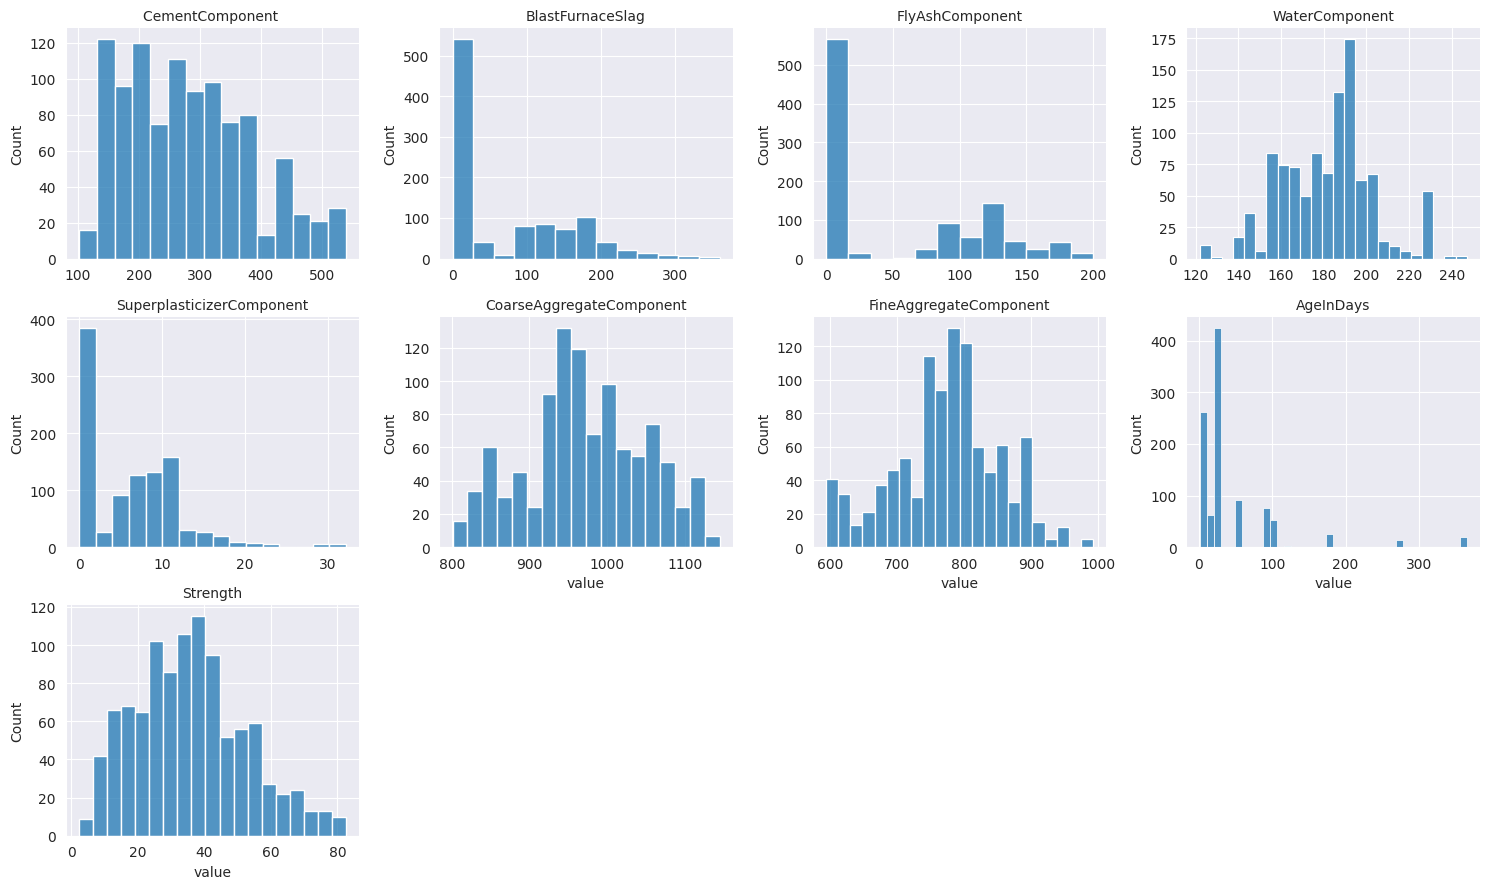

In [346]:
import numpy as np
from home_works.machine_learning.util import show_num_features_dist

data_num = df.select_dtypes(include=np.number)

show_num_features_dist(data_num)

Як бачимо, 6 із 9 ознак мають нормальний розподіл Гаусса-Лапласа чи близький до нього. Ця обставина вплинула на вибір мною функції кативації.

## Створення нової ознаки
Створюємо ознаку `Components`, котра підраховує кількість компонентів, котрі присутні в рецепті. Ця ознака описує кореляцію між ознаками та міцністю бетону. На мою думку, оеращить прогноз моделі.

In [347]:
columns = [c for c in df.columns if c not in ["CementComponent", "AgeInDays", "Strength"]]
df["Components"] = df[columns].gt(0).sum(axis=1)
df.head()

,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,5


## Видаляємо всі рядки з відсутніми даними та ще раз перерозбиваємо на дані та цільову змінну

In [348]:
df = df.dropna().reset_index(drop=True)
df.head()

,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,5


In [349]:
X = df.drop('Strength', axis =1).values
y = df['Strength'].values

## Масштабуємо дані за допомогою `StandardScaler`

In [350]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

X

array([[ 2.47791487, -0.85688789, -0.84714393, ..., -1.21767004,
        -0.27973311, -0.60246829],
       [ 2.47791487, -0.85688789, -0.84714393, ..., -1.21767004,
        -0.27973311, -0.60246829],
       [ 0.49142531,  0.79552649, -0.84714393, ..., -2.24091709,
         3.55306569, -0.60246829],
       ...,
       [-1.27008832,  0.75957923,  0.85063487, ...,  0.0801067 ,
        -0.27973311,  1.32468184],
       [-1.16860982,  1.30806485, -0.84714393, ...,  0.19116644,
        -0.27973311,  0.36110677],
       [-0.19403325,  0.30849909,  0.3769452 , ..., -0.15074782,
        -0.27973311,  1.32468184]], shape=(1030, 9))

## Розбиваємо дані на тренувальні та тестові

In [351]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X, y, random_state = 42, test_size =0.33)

In [352]:
import torch

X_train = torch.Tensor(X_train).float()
y_train = torch.Tensor(y_train).float()

X_test = torch.Tensor(X_test).float()
y_test = torch.Tensor(y_test).float()

print(X_train[:1])
print(y_train[:10])

tensor([[-1.2557,  1.8913, -0.8471, -0.3545,  0.9706,  1.2363, -1.2301, -0.2797,
          0.3611]])
tensor([37.4300, 26.0500, 38.8900, 26.1500, 11.4800, 33.0600, 15.6900, 67.3100,
        28.6300, 32.0700])


## Створення самої нейромережі

In [353]:
from torch import nn


class LinearModel(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=20, out_dim=3):
        super().__init__()

        self.features = torch.nn.Sequential(

            nn.Linear(in_dim, hidden_dim),
            torch.nn.SELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        output = self.features(x)
        return output


Оскільки ми не працюємо на задачу класифікації, отже, ми працюємо в регресії (адже міцність бетону - це неперервний числовий ряд, а не кілька кластерів). Як ми бачили по нашим графікам, більшість даних впадають у нормальний розподіл. До того ж ми провели стандартизацію даних через `StandardScaler`. Відповідно, функцією активації я обрав ≈`SELU`, котра добре працює саме в нормальному розподілі.

## Ініціалізуємо нашу нейромережу
Ініціалізуємо 20 прихованих шарів та 1 нейрон в фінальному шарі. Це пояснюється тим, що ми вирішуємо задачу лінійної регресії.

In [354]:
model = LinearModel(X_train.shape[1], 20, 1)

## Обираємо функцію втрат
Вибір середньоквадратичної помилки зумовлено тим, що наша задача - це саме регресія, а не класифікація.

In [355]:
criterion = nn.MSELoss()

## Обираємо функцію оптимізатор

In [356]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Застосовуємо нашу модель
Визначимол кількість епох. Я поклався на потужність свого компа і визначив їх 1000

In [357]:
num_epoch = 1000

Тренуємо модель:

In [358]:
train_loss = []
test_loss = []
train_maes = []
test_maes = []

In [359]:
model.train()

LinearModel(
  (features): Sequential(
    (0): Linear(in_features=9, out_features=20, bias=True)
    (1): SELU()
    (2): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [360]:
outputs = model(X_train)

## Обчислюємо кількість класів та застосовуємо функцію втрат

In [361]:
# Крок 1: Визначте кількість класів
num_classes = len(torch.unique(y_train))
print(f"Кількість класів: {num_classes}")

# Крок 2: Переконайтеся, що модель має правильну архітектуру
# model.fc_final = torch.nn.Linear(hidden_size, num_classes)

# Крок 3: Переконайтеся, що y_train має правильний тип даних
y_train = y_train.float()

# Крок 4: Тепер обчисліть loss
loss = criterion(outputs.squeeze(), y_train)
train_loss.append(loss.cpu().detach().numpy())

Кількість класів: 606


In [362]:
acc = 100 * torch.sum(y_train==torch.max(outputs.data, 1)[1]).double() / len(y_train)
train_maes.append(acc)

Переводимо модель в режим оцінювання.

In [363]:
model.eval()

LinearModel(
  (features): Sequential(
    (0): Linear(in_features=9, out_features=20, bias=True)
    (1): SELU()
    (2): Linear(in_features=20, out_features=1, bias=True)
  )
)

Зараз проведемо оцінку моделі

In [364]:
outputs = model(X_test)

loss = criterion(outputs, y_test)
test_loss.append(loss.cpu().detach().numpy())

acc = 100 * torch.sum(y_test==torch.max(outputs.data, 1)[1]).double() / len(y_test)
test_maes.append(acc)

/home/ubuntu/.virtualenvs/WoolfDataScience/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([340])) that is different to the input size (torch.Size([340, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


А тепер проведемо тренування моделі на 1000 епох

In [365]:
for epoch in range(num_epoch):

    # train the model
    model.train()

    outputs = model(X_train)

    loss = criterion(outputs.squeeze(), y_train)  # Додано .squeeze()
    train_loss.append(loss.cpu().detach().numpy())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Розрахунок MAE для регресії
    mae = torch.mean(torch.abs(outputs.squeeze() - y_train))
    train_maes.append(mae.cpu().detach().numpy())

    if (epoch + 1) % 10 == 0:
        print('Epoch [%d/%d] Loss: %.4f   MAE: %.4f'
              % (epoch + 1, num_epoch, loss.item(), mae.item()))

    # test the model
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)

        loss = criterion(outputs.squeeze(), y_test)
        test_loss.append(loss.cpu().detach().numpy())

        mae = torch.mean(torch.abs(outputs.squeeze() - y_test))
        test_maes.append(mae.cpu().detach().numpy())

Epoch [10/1000] Loss: 99.7920   MAE: 7.9220
Epoch [20/1000] Loss: 83.6229   MAE: 7.0403
Epoch [30/1000] Loss: 66.1667   MAE: 6.1405
Epoch [40/1000] Loss: 53.0566   MAE: 5.5332
Epoch [50/1000] Loss: 79.5087   MAE: 7.0973
Epoch [60/1000] Loss: 50.6078   MAE: 5.3819
Epoch [70/1000] Loss: 45.0677   MAE: 5.0736
Epoch [80/1000] Loss: 42.7486   MAE: 4.9218
Epoch [90/1000] Loss: 50.8556   MAE: 5.5190
Epoch [100/1000] Loss: 55.4821   MAE: 5.7686
Epoch [110/1000] Loss: 42.1035   MAE: 4.9261
Epoch [120/1000] Loss: 41.5449   MAE: 4.8986
Epoch [130/1000] Loss: 42.7093   MAE: 4.9993
Epoch [140/1000] Loss: 42.9833   MAE: 5.0221
Epoch [150/1000] Loss: 41.0632   MAE: 4.8810
Epoch [160/1000] Loss: 39.3688   MAE: 4.7463
Epoch [170/1000] Loss: 38.5463   MAE: 4.6848
Epoch [180/1000] Loss: 37.8826   MAE: 4.6361
Epoch [190/1000] Loss: 37.4206   MAE: 4.6035
Epoch [200/1000] Loss: 37.0108   MAE: 4.5725
Epoch [210/1000] Loss: 36.6612   MAE: 4.5485
Epoch [220/1000] Loss: 36.3375   MAE: 4.5233
Epoch [230/1000] Lo

Виведемо візуалізацію якості навчання моделі:

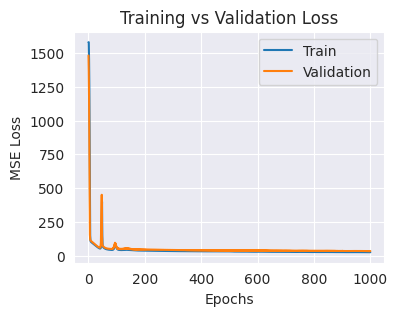

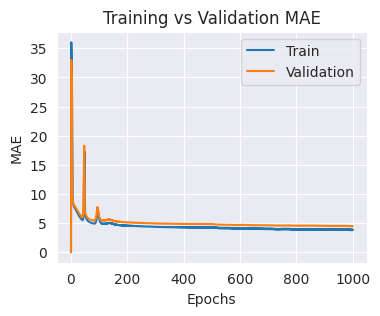

In [366]:
from matplotlib import pyplot as plt

plt.figure(figsize=(4, 3))
plt.plot(train_loss, label='Train')
plt.plot(test_loss, label='Validation')
plt.legend(loc='best')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')  # Змінено назву
plt.title('Training vs Validation Loss')
plt.show()
plt.figure(figsize=(4, 3))
plt.plot(train_maes, label='Train')  # Змінено з train_accs
plt.plot(test_maes, label='Validation')  # Змінено з test_accs
plt.legend(loc='best')
plt.xlabel('Epochs')
plt.ylabel('MAE')  # Змінено з Accuracy
plt.title('Training vs Validation MAE')
plt.show()

Як бачимо, дані тренувальні та валідаційні сходяться вже через 500 епох, що каже нам, що 500 епох достатньо і 1000 епох - це було переінженерювання.

## Метрики якості моделі

In [367]:
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Отримати передбачення моделі
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train).numpy()
    y_test_pred = model(X_test).numpy()

# Конвертувати таргети в numpy
y_train_np = y_train.numpy()
y_test_np = y_test.numpy()

# Обчислити метрики для тренувального набору
train_mse = mean_squared_error(y_train_np, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train_np, y_train_pred)
train_r2 = r2_score(y_train_np, y_train_pred)

# Обчислити метрики для тестового набору
test_mse = mean_squared_error(y_test_np, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_np, y_test_pred)
test_r2 = r2_score(y_test_np, y_test_pred)

# Вивести результати
print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ")
print("="*50)
print("\n📊 Тренувальний набір:")
print(f"  MSE (Mean Squared Error):     {train_mse:.4f}")
print(f"  RMSE (Root Mean Squared Error): {train_rmse:.4f}")
print(f"  MAE (Mean Absolute Error):    {train_mae:.4f}")
print(f"  R² Score:                     {train_r2:.4f}")

print("\n📊 Тестовий набір:")
print(f"  MSE (Mean Squared Error):     {test_mse:.4f}")
print(f"  RMSE (Root Mean Squared Error): {test_rmse:.4f}")
print(f"  MAE (Mean Absolute Error):    {test_mae:.4f}")
print(f"  R² Score:                     {test_r2:.4f}")
print("="*50)

МЕТРИКИ ЯКОСТІ МОДЕЛІ

📊 Тренувальний набір:
  MSE (Mean Squared Error):     25.6281
  RMSE (Root Mean Squared Error): 5.0624
  MAE (Mean Absolute Error):    3.7803
  R² Score:                     0.9078

📊 Тестовий набір:
  MSE (Mean Squared Error):     34.3179
  RMSE (Root Mean Squared Error): 5.8581
  MAE (Mean Absolute Error):    4.4772
  R² Score:                     0.8771
